### **Hamiltonian and Commutation Analysis**

We consider the Hamiltonian
$$
H = -g \frac{w_{0}}{2}X_0X_1 -g{\frac{w_{0}}{2}} Y_0Y_1 - g\frac{w_{1}}{2} X_1X_2 - g\frac{w_{1}}{2} Y_1Y_2 .
$$
The corresponding unitary time evolution is
$$
U(t) = e^{-itH}.
$$
If a Hamiltonian can be written as a sum of commuting parts, \( H = A + B \) with \( [A,B]=0 \), then the unitary evolution factorizes exactly as
$$
e^{-itH} = e^{-itA} e^{-itB}.
$$
If the terms do not commute, this exact factorization is not possible.

We group the Hamiltonian as
$$
H = aH_{01} + bH_{12},
$$
where
$$
H_{01} = X_0X_1 + Y_0Y_1, \quad
H_{12} = X_1X_2 + Y_1Y_2.
$$
and $a = -g\frac{w_{0}}{2}$ and $b = -g\frac{w_{1}}{2}$


Within each group, the terms commute:
$$
[X_0X_1, Y_0Y_1] = 0, \quad
[X_1X_2, Y_1Y_2] = 0.
$$
However, the two groups share qubit 1, and Pauli operators acting on the same qubit do not commute. Consequently,
$$
[H_{01}, H_{12}] \neq 0,
$$
and the full Hamiltonian contains non-commuting terms.

### **Trotterized Time Evolution**

Since the Hamiltonian terms do not commute, the exact unitary evolution cannot be written as a single product of exponentials. To approximate the evolution, we use the Suzuki–Trotter decomposition.

The first-order Trotter approximation is
$$
e^{-itH}
\approx
\left(
e^{-i\Delta t a H_{01}}
e^{-i\Delta t b H_{12}}
\right)^n,
\quad
\Delta t = \frac{t}{n}.
$$

The approximation improves as the number of Trotter steps $n$ increases and becomes exact in the limit $n \to \infty$.

### **Circuit Construction**

We'll use the same method that we have used in our original document to create circuit for both $H_{01}$ and $H_{12}$. We start from $-Z_{0}$ as our simple Hamiltonian and try to reach the desired unitaries using 
$$
H = U^{\dagger} H_{0} U
$$
In case of $H_{01}$, we have two unitaries and there corresponding gate decomposition follows 
- **STRING 1**: $X_{0}X_{1}$
$$
e^{ i \theta_{0}  X_{0}X_{1}} = U^{\dagger} (Z_{0}) U
$$
where $\theta_{0} = \frac{gw_{0}}{2} \Delta t$ and,
$$
U = e^{i \frac{\pi}{4} X_{0}} e^{i \frac{\pi}{4}Z_{0}X_{1}}
$$
with
$$
e^{i \frac{\pi}{4}Z_{0}X_{1}} = e^{i \frac{\pi}{4} X_{1}} e^{i \frac{\pi}{4}Z_{0}} e^{-i \frac{\pi}{4}}CNOT^{0 \to 1}
$$
Hence, we can write the full circuit as
$$
e^{- i \Delta t a X_{0}X_{1}}  = CNOT^{0 \to 1} S_{0} R_{0}^{x}\left(\frac{\pi}{2}\right) \times \left(U_{1}^{0}(\theta_{0})\right)^{\dagger} \times  R_{0}^{x}\left(-\frac{\pi}{2}\right)S_{0}^{\dagger} CNOT^{0 \to 1} \tag{1}
$$
- **STRING 2**:  $Y_{0}Y_{1}$
In this case, we'll need two extra rotations, hence we get
$$
U = e^{i \frac{\pi}{4} X_{0}} e^{i \frac{\pi}{4}Z_{0}X_{1}} e^{i \frac{\pi}{4} Z_{0}} e^{i \frac{\pi}{4} Z_{1}}
$$
and the corresponding circuit will be, 
$$
e^{i \theta_{0} Y_{0}Y_{1}} = S_{0}S_{1} CNOT^{0 \to 1} S_{0} R_{0}^{x}\left(\frac{\pi}{2}\right) \times \left(U_{1}^{0}(\theta_{0})\right)^{\dagger} \times R_{0}^{x}\left(-\frac{\pi}{2}\right) S_{0}^{\dagger} CNOT^{0 \to 1}  S_{1}^{\dagger} S_{0}^{\dagger} \tag{2}
$$

Similarly, In case of H_{12},
- **STRING 1**: $X_{1}X_{2}$
This is similar as for string 1 of $H_{01}$, we just need to replace $0 \to 1$, $1 \to 2$, and $\theta_{0} \to \theta_{1}$, where $\theta_{1} = \frac{gw_{1}}{2}\Delta t$,
$$
e^{i \theta_{1} X_{1}X_{2}} =  CNOT^{1 \to 2} S_{1} R_{1}^{x}\left(\frac{\pi}{2}\right) \times \left(U_{1}^{1}(\theta_{1})\right)^{\dagger} \times  R_{1}^{x}\left(-\frac{\pi}{2}\right)S_{1}^{\dagger} CNOT^{1 \to 2} \tag{3}
$$
- **STRING 2**: $Y_{1}Y_{2}$
This one is similar to string 2 of $H_{01}$, with same replacements as previous, hence

$$
e^{i \theta_{1} Y_{1}Y_{2}} = S_{1}S_{2} CNOT^{1 \to 2} S_{1} R_{1}^{x}\left(\frac{\pi}{2}\right) \times \left(U_{1}^{1}(\theta_{1})\right)^{\dagger} \times R_{1}^{x}\left(-\frac{\pi}{2}\right) S_{1}^{\dagger} CNOT^{1 \to 2}  S_{2}^{\dagger} S_{1}^{\dagger} \tag{4}
$$


We can now put these together to create circuit for the unitary evolution of our Hamiltonian.

In [11]:
import qiskit
from qiskit import QuantumCircuit, transpile, ClassicalRegister, QuantumRegister
from qiskit.visualization import plot_histogram,plot_distribution
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
from qiskit_aer import Aer, AerSimulator
from qiskit.circuit.library import UGate
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import pylatexenc
import numpy as np
import math

#### **Simple Circuit**

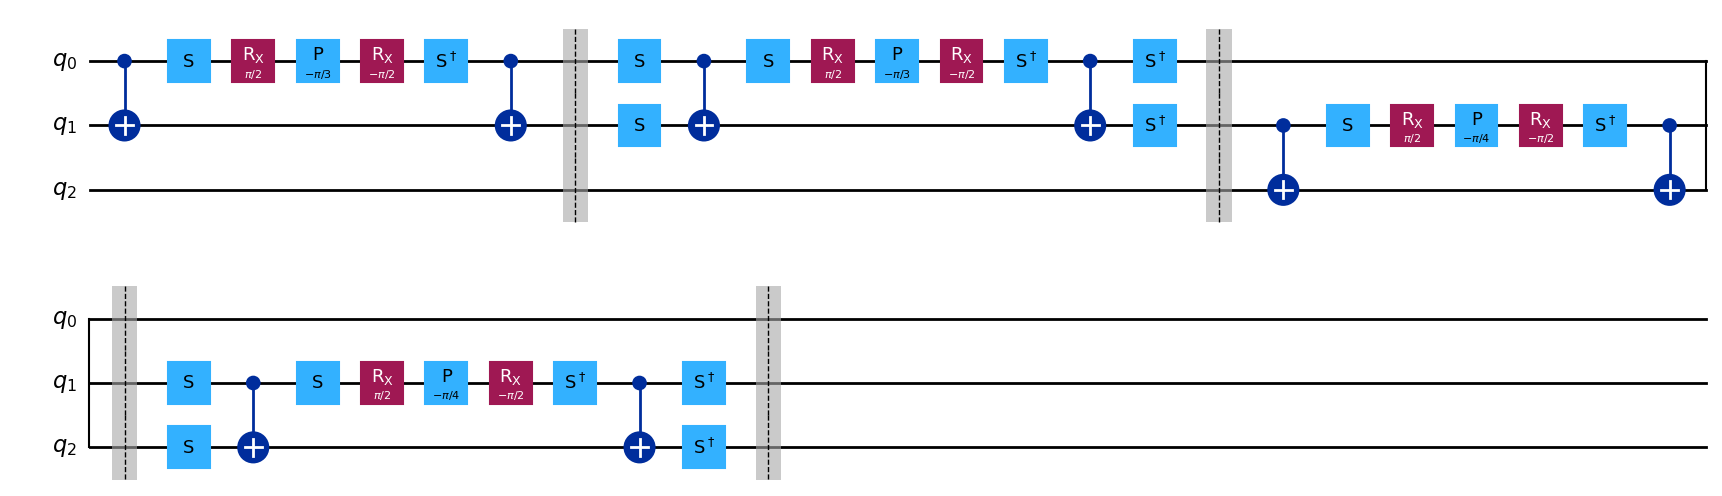

In [2]:
# Random angles
theta_0 = np.pi / 3
theta_1 = np.pi / 4

# Largest qubit index is 2, so we need 3 qubits
qc = QuantumCircuit(3)

# ----------------- Subcircuit 1 -----------------
qc.cx(0, 1)
qc.s(0)
qc.rx(np.pi/2, 0)
qc.p(-theta_0, 0)  # U1^0†
qc.rx(-np.pi/2, 0)
qc.sdg(0)
qc.cx(0, 1)
qc.barrier()

# ----------------- Subcircuit 2 -----------------
qc.s(0)
qc.s(1)
qc.cx(0, 1)
qc.s(0)
qc.rx(np.pi/2, 0)
qc.p(-theta_0, 0)  # U1^0†
qc.rx(-np.pi/2, 0)
qc.sdg(0)
qc.cx(0, 1)
qc.sdg(1)
qc.sdg(0)
qc.barrier()

# ----------------- Subcircuit 3 -----------------
qc.cx(1, 2)
qc.s(1)
qc.rx(np.pi/2, 1)
qc.p(-theta_1, 1)  # U1^1†
qc.rx(-np.pi/2, 1)
qc.sdg(1)
qc.cx(1, 2)
qc.barrier()

# ----------------- Subcircuit 4 -----------------
qc.s(1)
qc.s(2)
qc.cx(1, 2)
qc.s(1)
qc.rx(np.pi/2, 1)
qc.p(-theta_1, 1)  # U1^1†
qc.rx(-np.pi/2, 1)
qc.sdg(1)
qc.cx(1, 2)
qc.sdg(2)
qc.sdg(1)
qc.barrier()

# Draw the full circuit
qc.draw('mpl')


#### **Trotterization and Running on real backend**

In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(
token="MyecTEwFVnhiA01nNvaqhXmIz6Z72cmU56ovGaytiO7g", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
instance="crn:v1:bluemix:public:quantum-computing:us-east:a/6f5d2cd8cddd46e9b5634b2c700fb95a:b5b5f0a4-24fe-476c-977a-cbc7c761049a::", # Optional
overwrite = True 
)
service = QiskitRuntimeService()
# service.saved_accounts() # To chek the account is saved successfully
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
backend.name

'ibm_marrakesh'

In [4]:
def build_circuit(eps, troter_steps):
    # DEFINE VARIABLES
    gup_coeff = 0.009
    w0 = 1 - (2 * gup_coeff)
    w1 = math.sqrt(2) - (4 * gup_coeff)
    theta_0 = (w0 * eps) / 2
    theta_1 = (w1 * eps) / 2
    # print(theta_1, theta_2, theta_3, theta_4)
    # FOR TROTTERIZATION
    dtheta_0 = theta_0 / troter_steps
    dtheta_1 = theta_1 / troter_steps
    q0 = QuantumRegister(1, "q0")
    q1 = QuantumRegister(1,"q1")
    q2 = QuantumRegister(1,"q2")

    creg = ClassicalRegister(3,name = "measurement")
    qc = QuantumCircuit(q0,q1,q2, creg)
    # INITIAL STATE 001001
    qc.x(q2)
    for _ in range(troter_steps):
        qc.cx(0, 1)
        qc.s(0)
        qc.rx(np.pi/2, 0)
        qc.p(-dtheta_0, 0)  # U1^0†
        qc.rx(-np.pi/2, 0)
        qc.sdg(0)
        qc.cx(0, 1)
        qc.barrier()

        # ----------------- Subcircuit 2 -----------------
        qc.s(0)
        qc.s(1)
        qc.cx(0, 1)
        qc.s(0)
        qc.rx(np.pi/2, 0)
        qc.p(-dtheta_0, 0)  # U1^0†
        qc.rx(-np.pi/2, 0)
        qc.sdg(0)
        qc.cx(0, 1)
        qc.sdg(1)
        qc.sdg(0)
        qc.barrier()

        # ----------------- Subcircuit 3 -----------------
        qc.cx(1, 2)
        qc.s(1)
        qc.rx(np.pi/2, 1)
        qc.p(-dtheta_1, 1)  # U1^1†
        qc.rx(-np.pi/2, 1)
        qc.sdg(1)
        qc.cx(1, 2)
        qc.barrier()

        # ----------------- Subcircuit 4 -----------------
        qc.s(1)
        qc.s(2)
        qc.cx(1, 2)
        qc.s(1)
        qc.rx(np.pi/2, 1)
        qc.p(-dtheta_1, 1)  # U1^1†
        qc.rx(-np.pi/2, 1)
        qc.sdg(1)
        qc.cx(1, 2)
        qc.sdg(2)
        qc.sdg(1)
        qc.barrier()
    qc.measure([0,1,2],[0,1,2])
    return qc
all_circuits = []
metadata = []
# eps_list = [0.001,0.002,0.003,0.004,0.005,0.006] # math.pow(10,-3), math.pow(10,-5) 
eps_list =  np.linspace(0.15, 0.25, 25)
troter_steps = [20]
for steps in troter_steps:
    for eps in eps_list:

        qc = build_circuit(eps, steps)

        all_circuits.append(qc)
        metadata.append((steps, eps))

# -----------------------------------
# 2️⃣ Transpile ALL circuits together
# -----------------------------------
transpiled_circuits = transpile(all_circuits, backend, optimization_level=3)

# -----------------------------------
# 3️⃣ Submit ONE job
# -----------------------------------
sampler = Sampler(mode=backend)

job = sampler.run(transpiled_circuits, shots=1024)
print("Job ID:", job.job_id())
print("Backend:", backend.name)
print("Status:", job.status())
job_result = job.result()

# -----------------------------------
# 4️⃣ Organize results nicely
# -----------------------------------
results = {}

for i, (steps, eps) in enumerate(metadata):

    counts = job_result[i].data.measurement.get_counts()

    if steps not in results:
        results[steps] = {}

    results[steps][eps] = counts

# -----------------------------------
# 5️⃣ Print clean output
# -----------------------------------
for steps in results:
    print("\n==============================")
    print("Trotter steps =", steps)
    print("==============================")

    for eps in results[steps]:
        print(f"eps = {eps} → {results[steps][eps]}")

Job ID: d6ftme8ddp9c73cesav0
Backend: ibm_marrakesh
Status: QUEUED

Trotter steps = 20
eps = 0.15 → {'110': 93, '000': 191, '100': 495, '010': 62, '011': 20, '111': 68, '001': 26, '101': 69}
eps = 0.15416666666666667 → {'111': 62, '000': 114, '110': 90, '100': 615, '101': 82, '010': 38, '001': 12, '011': 11}
eps = 0.15833333333333333 → {'100': 626, '110': 130, '010': 43, '000': 68, '111': 54, '101': 73, '011': 18, '001': 12}
eps = 0.1625 → {'100': 626, '000': 74, '101': 84, '110': 112, '111': 69, '010': 36, '011': 13, '001': 10}
eps = 0.16666666666666666 → {'100': 517, '111': 62, '000': 172, '010': 66, '001': 30, '110': 116, '101': 42, '011': 19}
eps = 0.17083333333333334 → {'100': 482, '111': 60, '110': 129, '000': 186, '101': 55, '011': 24, '010': 66, '001': 22}
eps = 0.175 → {'100': 522, '101': 80, '010': 57, '111': 79, '110': 163, '001': 18, '011': 18, '000': 87}
eps = 0.17916666666666667 → {'111': 100, '000': 80, '100': 496, '110': 172, '010': 59, '011': 13, '101': 89, '001': 15}


In [5]:
def counts_to_probs(counts_dict):
    shots = sum(counts_dict.values())
    return {k: v / shots for k, v in counts_dict.items()}

allowed = ['001','010','100'] 

# Convert counts → probabilities
probs = counts_to_probs(results[steps][eps])

# Compute total probability inside allowed subspace
total = sum(probs.get(k, 0.0) for k in allowed)

# Avoid division by zero
if total == 0:
    print("No allowed states measured!")
    postselected_probs = {k: 0 for k in allowed}
else:
    postselected_probs = {k: probs.get(k, 0.0) / total for k in allowed}

print(postselected_probs)

{'001': 0.03367003367003367, '010': 0.0707070707070707, '100': 0.8956228956228957}


In [7]:
def compute_true_probabilities(eps_list, trotter_steps):
    true_results = {}

    for steps in trotter_steps:
        true_results[steps] = {}

        for eps in eps_list:

            # Build circuit
            qc = build_circuit(eps, steps)

            # Remove measurements (important!)
            qc_no_meas = qc.remove_final_measurements(inplace=False)

            # Get exact statevector
            state = Statevector.from_instruction(qc_no_meas)

            # Convert to probabilities
            probs = state.probabilities_dict()

            true_results[steps][eps] = probs

    return true_results
true_probs = compute_true_probabilities(eps_list, troter_steps)
print(true_probs)

{20: {np.float64(0.15): {np.str_('001'): np.float64(1.3043088701733333e-05), np.str_('010'): np.float64(0.010628703872065087), np.str_('100'): np.float64(0.9893582530392568), np.str_('111'): np.float64(4.807492714954836e-33)}, np.float64(0.15416666666666667): {np.str_('001'): np.float64(1.4551740156698804e-05), np.str_('010'): np.float64(0.011224074097318609), np.str_('100'): np.float64(0.9887613741625512), np.str_('111'): np.float64(1.925929944387236e-34)}, np.float64(0.15833333333333333): {np.str_('001'): np.float64(1.6187444809141254e-05), np.str_('010'): np.float64(0.011835388558874284), np.str_('100'): np.float64(0.9881484239963385), np.str_('111'): np.float64(2.4676459365145297e-32)}, np.float64(0.1625): {np.str_('001'): np.float64(1.7957112804443494e-05), np.str_('010'): np.float64(0.012462617619119667), np.str_('100'): np.float64(0.9875194252680964), np.str_('111'): np.float64(1.2600276760729707e-32)}, np.float64(0.16666666666666666): {np.str_('001'): np.float64(1.9867833217209

In [8]:
def classical_fidelity(p_true, p_exp):
    all_keys = set(p_true.keys()).union(set(p_exp.keys()))
    fidelity_sum = 0.0

    for key in all_keys:
        pt = p_true.get(key, 0.0)
        pe = p_exp.get(key, 0.0)
        fidelity_sum += np.sqrt(pt * pe)

    return fidelity_sum**2

fidelity_results = {}

for steps in results:
    fidelity_results[steps] = {}

    for eps in results[steps]:

        # Exact probabilities from statevector
        p_true = true_probs[steps][eps]

        # Hardware probabilities → apply postselection
        counts = results[steps][eps]
        p_raw = counts_to_probs(counts)

        # Apply postselection: keep only keys present in ideal probs
        allowed_keys = p_true.keys()
        total = sum(p_raw[k] for k in allowed_keys if k in p_raw)
        p_exp = {k: p_raw.get(k, 0.0)/total for k in allowed_keys}

        # Compute classical fidelity using postselected probs
        F = classical_fidelity(p_true, p_exp)

        fidelity_results[steps][eps] = F

        print(f"Trotter steps = {steps}, eps = {eps} → Fidelity = {100 * F:.6f}")

Trotter steps = 20, eps = 0.15 → Fidelity = 80.977823
Trotter steps = 20, eps = 0.15416666666666667 → Fidelity = 88.224642
Trotter steps = 20, eps = 0.15833333333333333 → Fidelity = 89.154956
Trotter steps = 20, eps = 0.1625 → Fidelity = 88.073967
Trotter steps = 20, eps = 0.16666666666666666 → Fidelity = 82.110133
Trotter steps = 20, eps = 0.17083333333333334 → Fidelity = 82.353203
Trotter steps = 20, eps = 0.175 → Fidelity = 82.457277
Trotter steps = 20, eps = 0.17916666666666667 → Fidelity = 79.411731
Trotter steps = 20, eps = 0.18333333333333332 → Fidelity = 87.378933
Trotter steps = 20, eps = 0.1875 → Fidelity = 70.206966
Trotter steps = 20, eps = 0.19166666666666665 → Fidelity = 92.217917
Trotter steps = 20, eps = 0.19583333333333333 → Fidelity = 85.132527
Trotter steps = 20, eps = 0.2 → Fidelity = 81.744923
Trotter steps = 20, eps = 0.20416666666666666 → Fidelity = 96.138040
Trotter steps = 20, eps = 0.20833333333333331 → Fidelity = 89.739619
Trotter steps = 20, eps = 0.2125 → F

In [9]:
# -----------------------------------
# Filter eps values by fidelity
# -----------------------------------

FIDELITY_THRESHOLD = 0.90   # 80%

high_fidelity_eps = []

# Since you only have one Trotter step, access it directly
steps = troter_steps[0]  # 5 in your case

for eps, F in fidelity_results[steps].items():
    if F >= FIDELITY_THRESHOLD:
        high_fidelity_eps.append((eps, F))

# Sort by fidelity (highest first)
high_fidelity_eps.sort(key=lambda x: x[1], reverse=True)

# Print results
print(f"\nEpsilon values with fidelity ≥ {100*FIDELITY_THRESHOLD:.0f}% for {steps} Trotter steps:")
for eps, F in high_fidelity_eps:
    print(f"eps = {eps:.6f}, Fidelity = {100*F:.2f}%")


Epsilon values with fidelity ≥ 90% for 20 Trotter steps:
eps = 0.204167, Fidelity = 96.14%
eps = 0.241667, Fidelity = 92.74%
eps = 0.250000, Fidelity = 92.25%
eps = 0.191667, Fidelity = 92.22%
eps = 0.245833, Fidelity = 91.64%
eps = 0.225000, Fidelity = 91.39%


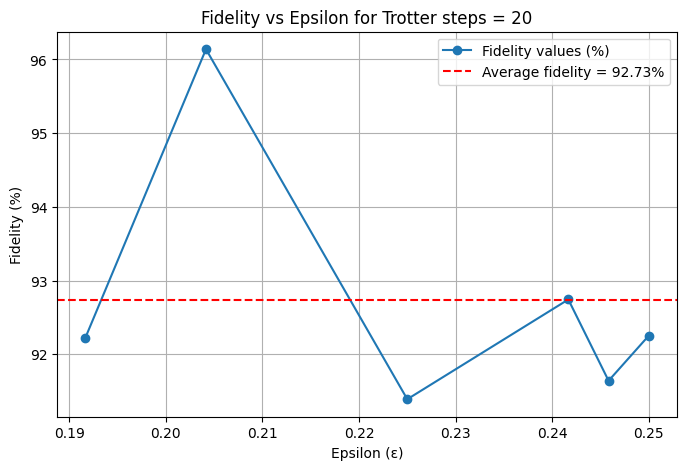

In [12]:
# Extract epsilon and fidelity values
eps_values = np.array([eps for eps, F in high_fidelity_eps])
fidelity_values = np.array([F for eps, F in high_fidelity_eps])

# Convert to percentage
fidelity_values_percent = fidelity_values * 100

# Average fidelity
avg_fidelity_percent = np.mean(fidelity_values_percent)

# Sort by epsilon
sorted_indices = np.argsort(eps_values)
eps_sorted = eps_values[sorted_indices]
fidelity_sorted = fidelity_values_percent[sorted_indices]

# Plot
plt.figure(figsize=(8,5))
plt.plot(eps_sorted, fidelity_sorted, 'o-', label='Fidelity values (%)')

# Average line
plt.axhline(avg_fidelity_percent, color='r', linestyle='--', label=f'Average fidelity = {avg_fidelity_percent:.2f}%')

plt.xlabel('Epsilon (ε)')
plt.ylabel('Fidelity (%)')
plt.title(f'Fidelity vs Epsilon for Trotter steps = {troter_steps[0]}')
plt.legend()
plt.grid(True)
plt.show()

### **Trotterization**

In [ ]:
# # Parameters
# g = 9.8
# w0_0 = 0.1
# w0_1 = 0.2
# n = 50  # number of Trotter steps

# theta_0 = g * w0_0 / (2 * n)
# theta_1 = g * w0_1 / (2 * n)

# # Initialize 3-qubit circuit
# qreg = QuantumRegister(3, name="q")
# creg = ClassicalRegister(3, name="c")
# trot_qc = QuantumCircuit(qreg,creg)

# # ----------------- Set initial state |0 0 1> -----------------
# trot_qc.x(2)  # Flip qubit 2 to |1>, qubits 0 and 1 are already |0>

# # Build Trotterized circuit
# for step in range(1, n+1):
#     trot_qc.barrier()  # separate Trotter steps visually

#     # ----------------- Subcircuit 1 -----------------
#     trot_qc.cx(0, 1)
#     trot_qc.s(0)
#     trot_qc.rx(np.pi/2, 0)
#     trot_qc.p(-theta_0, 0)  # U1^0†
#     trot_qc.rx(-np.pi/2, 0)
#     trot_qc.sdg(0)
#     trot_qc.cx(0, 1)

#     # ----------------- Subcircuit 2 -----------------
#     trot_qc.s(0)
#     trot_qc.s(1)
#     trot_qc.cx(0, 1)
#     trot_qc.s(0)
#     trot_qc.rx(np.pi/2, 0)
#     trot_qc.p(-theta_0, 0)  # U1^0†
#     trot_qc.rx(-np.pi/2, 0)
#     trot_qc.sdg(0)
#     trot_qc.cx(0, 1)
#     trot_qc.sdg(1)
#     trot_qc.sdg(0)

#     # ----------------- Subcircuit 3 -----------------
#     trot_qc.cx(1, 2)
#     trot_qc.s(1)
#     trot_qc.rx(np.pi/2, 1)
#     trot_qc.p(-theta_1, 1)  # U1^1†
#     trot_qc.rx(-np.pi/2, 1)
#     trot_qc.sdg(1)
#     trot_qc.cx(1, 2)

#     # ----------------- Subcircuit 4 -----------------
#     trot_qc.s(1)
#     trot_qc.s(2)
#     trot_qc.cx(1, 2)
#     trot_qc.s(1)
#     trot_qc.rx(np.pi/2, 1)
#     trot_qc.p(-theta_1, 1)  # U1^1†
#     trot_qc.rx(-np.pi/2, 1)
#     trot_qc.sdg(1)
#     trot_qc.cx(1, 2)
#     trot_qc.sdg(2)
#     trot_qc.sdg(1)

# # Final barrier
# trot_qc.barrier()
# trot_qc.measure([0,1,2], [0,1,2])

# # Draw the Trotterized circuit with initial state
# # trot_qc.draw('mpl')


Raw Counts: {'100': 316, '010': 672, '001': 36}


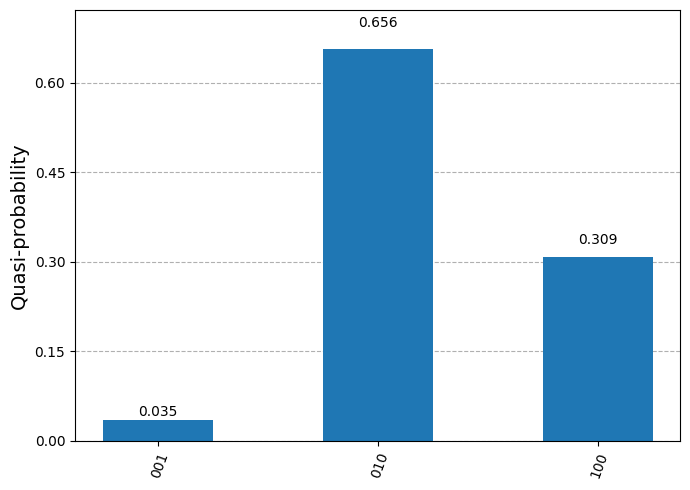

In [35]:
backend = AerSimulator()
pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=2)
trotqc_transpiled = pass_manager.run(trot_qc)

sampler = Sampler(mode=backend)
job_result = sampler.run([trotqc_transpiled], shots=1024).result()
counts = job_result[0].data.c.get_counts()
# Note: The exact access pattern may vary with Qiskit version;
# sometimes it's .data.c or .data.meas — adjust accordingly based on your transpiled circuit.

print("Raw Counts:", counts)
plot_distribution(counts)